Dataset Info:
Shape: (9994, 11)
Columns: ['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City', 'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State']

First 5 rows:
  Order ID Customer Name          Category      Sub Category         City  \
0      OD1        Harish      Oil & Masala           Masalas      Vellore   
1      OD2         Sudha         Beverages     Health Drinks  Krishnagiri   
2      OD3       Hussain       Food Grains      Atta & Flour   Perambalur   
3      OD4       Jackson  Fruits & Veggies  Fresh Vegetables   Dharmapuri   
4      OD5       Ridhesh       Food Grains   Organic Staples         Ooty   

   Order Date Region  Sales  Discount  Profit       State  
0  11-08-2017  North   1254      0.12  401.28  Tamil Nadu  
1  11-08-2017  South    749      0.18  149.80  Tamil Nadu  
2  06-12-2017   West   2360      0.21  165.20  Tamil Nadu  
3  10-11-2016  South    896      0.25   89.60  Tamil Nadu  
4  10-11-2016  South   2355      0.26  918.45  Tami

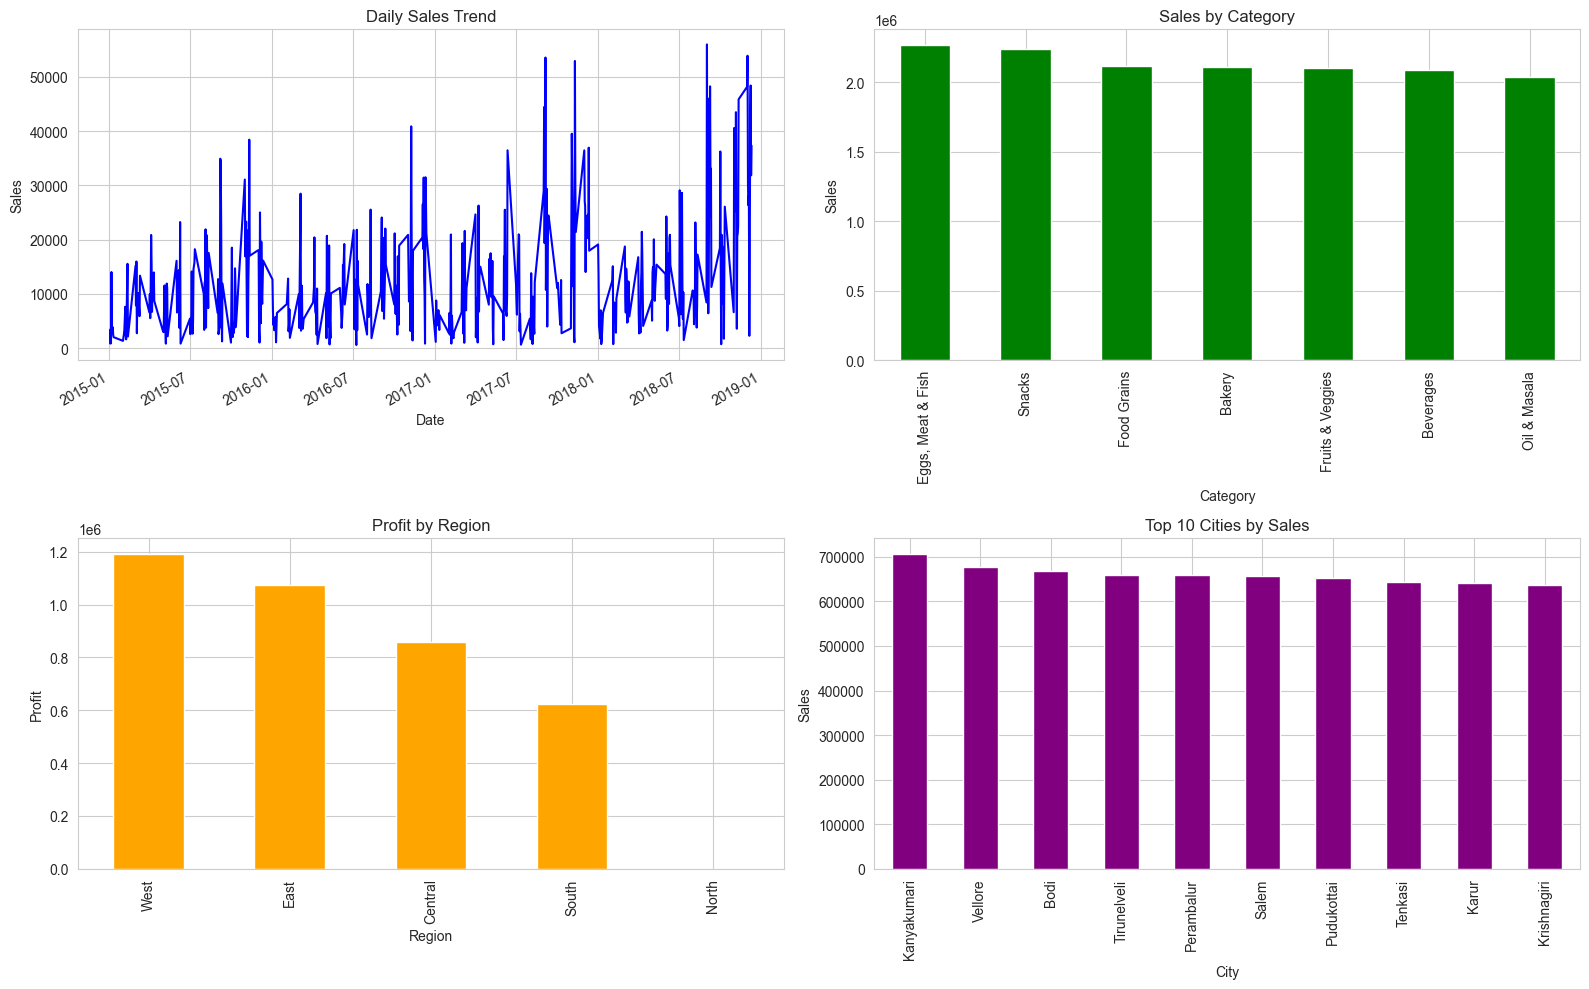

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load and explore data
def load_and_explore_sales(filename):
    df = pd.read_csv(filename)
    df.columns = df.columns.str.strip()

    print("Dataset Info:")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print("\nFirst 5 rows:")
    print(df.head())
    print("\nMissing values:")
    print(df.isnull().sum())

    return df

# Sales analysis
def analyze_sales(df):
    if 'Order Date' in df.columns:
        df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

    daily_sales = df.groupby('Order Date')['Sales'].sum().sort_index()
    category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
    region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
    city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)
    discount_profit = df.groupby('Category')[['Discount', 'Profit']].mean()

    return daily_sales, category_sales, region_profit, city_sales, discount_profit

# Visualization
def plot_sales_insights(daily_sales, category_sales, region_profit, city_sales):
    plt.figure(figsize=(16, 10))

    plt.subplot(2, 2, 1)
    daily_sales.plot(color='blue')
    plt.title('Daily Sales Trend')
    plt.xlabel('Date')
    plt.ylabel('Sales')

    plt.subplot(2, 2, 2)
    category_sales.plot(kind='bar', color='green')
    plt.title('Sales by Category')
    plt.xlabel('Category')
    plt.ylabel('Sales')

    plt.subplot(2, 2, 3)
    region_profit.plot(kind='bar', color='orange')
    plt.title('Profit by Region')
    plt.xlabel('Region')
    plt.ylabel('Profit')

    plt.subplot(2, 2, 4)
    city_sales.plot(kind='bar', color='purple')
    plt.title('Top 10 Cities by Sales')
    plt.xlabel('City')
    plt.ylabel('Sales')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    df = load_and_explore_sales(r"C:\Users\Dell\Desktop\Task2\Supermart Market.csv")
    daily_sales, category_sales, region_profit, city_sales, discount_profit = analyze_sales(df)
    print("\nAverage Discount and Profit by Category:")
    print(discount_profit)
    plot_sales_insights(daily_sales, category_sales, region_profit, city_sales)


# Sales Analysis Report

## Objective
The objective of this project is to analyze retail grocery sales data and identify meaningful business insights.

## Dataset Features
- Order Date
- Category
- Sub Category
- City
- Region
- Sales
- Discount
- Profit

## Analysis Performed
- Daily sales trend analysis
- Category-wise sales comparison
- Region-wise profit analysis
- Top cities by sales
- Discount and profit comparison by category

## Key Insights
- Sales trend analysis helps detect high and low performance periods.
- Category analysis highlights top revenue-generating product groups.
- Region-wise profit shows where business is most profitable.
- City-level analysis identifies strong local markets.
- Discount-profit comparison helps understand whether discounts are helping or hurting profitability.

## Conclusion
This project demonstrates practical retail analysis using grouping, aggregation, and visualization techniques in Python.
